# Longitudinal Coverage of Swissport Curated Annotations over Experimental Annotations

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

releases = ['2017_01', '2018_01', '2019_01', '2020_01', '2021_01', '2022_01', '2023_01', '2024_01']
base_path = '/home/atoffano/PFP_layer/data/swissprot'

def load_annotations_set(release, type_suffix):
    """
    Loads annotations from a TSV file and returns a set of (EntryID, GO_term) tuples.
    type_suffix example: "BPO_exp_annotations" or "BPO_annotations"
    """
    filename = f"swissprot_{release}_{type_suffix}.tsv"
    file_path = os.path.join(base_path, release, filename)
    
    if not os.path.exists(file_path):
        print(f"Warning: File not found {file_path}")
        return set()

    df = pd.read_csv(file_path, sep='\t', usecols=['EntryID', 'term'])
    df = df.dropna(subset=['term'])
    df['term'] = df['term'].str.split('; ')
    df_exploded = df.explode('term')
    
    # Return as set of tuples
    return set(zip(df_exploded['EntryID'], df_exploded['term']))

Starting computation...
Loading curated annotations for 2017_01...
Loading experimental annotations for 2017_01...
Loading experimental annotations for 2018_01...
Loading experimental annotations for 2019_01...
Loading experimental annotations for 2020_01...
Loading experimental annotations for 2021_01...
Loading experimental annotations for 2022_01...
Loading experimental annotations for 2023_01...
Loading experimental annotations for 2024_01...
Loading curated annotations for 2018_01...
Loading curated annotations for 2019_01...
Loading curated annotations for 2020_01...
Loading curated annotations for 2021_01...
Loading curated annotations for 2022_01...
Loading curated annotations for 2023_01...
Loading curated annotations for 2024_01...


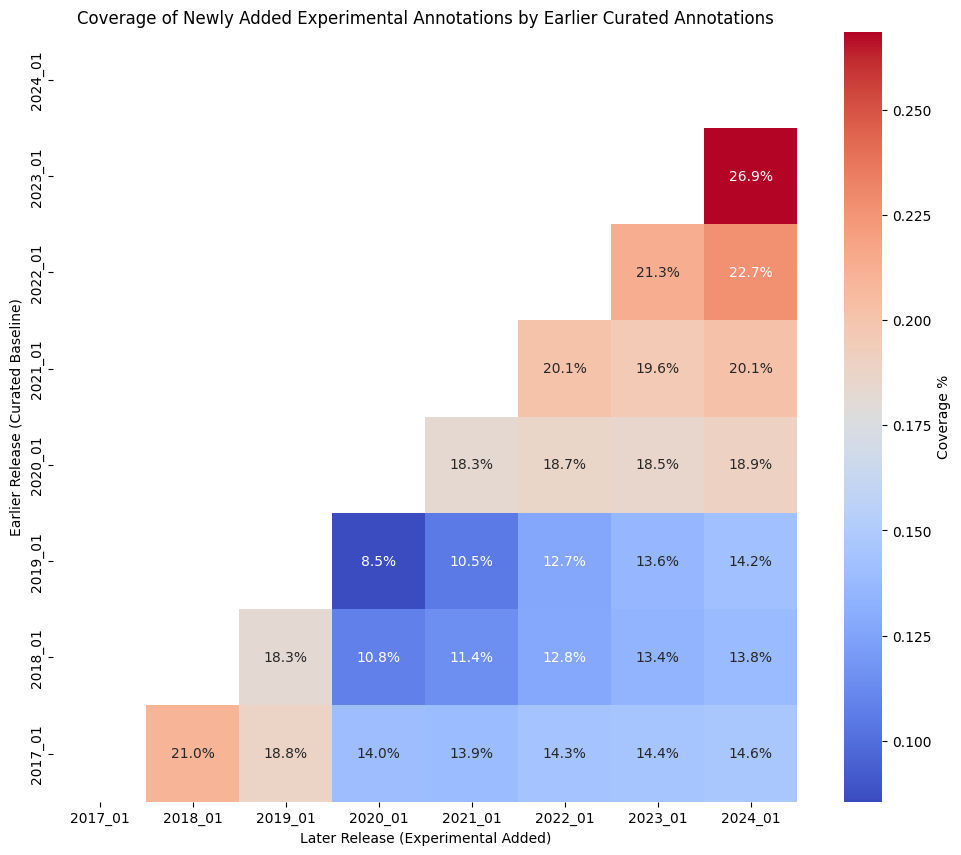

In [5]:
# Initialize results matrix
matrix = pd.DataFrame(index=releases, columns=releases, dtype=float)

# Caches to minimize reloading
exp_annotations_cache = {}
curated_annotations_cache = {}

print("Starting computation...")

for i, earlier_release in enumerate(releases):
    # Load Earliest Curated Annotations (Predictions)
    if earlier_release not in curated_annotations_cache:
        print(f"Loading curated annotations for {earlier_release}...")
        curated_annotations_cache[earlier_release] = load_annotations_set(earlier_release, "BPO_annotations")
    curated_earlier = curated_annotations_cache[earlier_release]
    
    # Load Earliest Experimental Annotations (Baseline for 'Newly Added')
    if earlier_release not in exp_annotations_cache:
        print(f"Loading experimental annotations for {earlier_release}...")
        exp_annotations_cache[earlier_release] = load_annotations_set(earlier_release, "BPO_exp_annotations")
    exp_earlier = exp_annotations_cache[earlier_release]

    for j in range(i + 1, len(releases)):
        later_release = releases[j]
        
        # Load Later Experimental Annotations
        if later_release not in exp_annotations_cache:
            print(f"Loading experimental annotations for {later_release}...")
            exp_annotations_cache[later_release] = load_annotations_set(later_release, "BPO_exp_annotations")
        exp_later = exp_annotations_cache[later_release]
        
        # newly added experimental annotations = (Exp_Later - Exp_Earlier)
        newly_added = exp_later - exp_earlier
        
        if len(newly_added) == 0:
            coverage = 0.0
        else:
            # Correctly predicted = newly added INTERSECT curated earlier
            correctly_predicted = newly_added.intersection(curated_earlier)
            coverage = len(correctly_predicted) / len(newly_added)
        
        matrix.loc[earlier_release, later_release] = coverage

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(matrix.iloc[::-1], annot=True, fmt=".1%", cmap="coolwarm", cbar_kws={'label': 'Coverage %'})
plt.title("Coverage of Newly Added Experimental Annotations by Earlier Curated Annotations")
plt.xlabel("Later Release (Experimental Added)")
plt.ylabel("Earlier Release (Curated Baseline)")
plt.show()

Starting computation for total coverage...


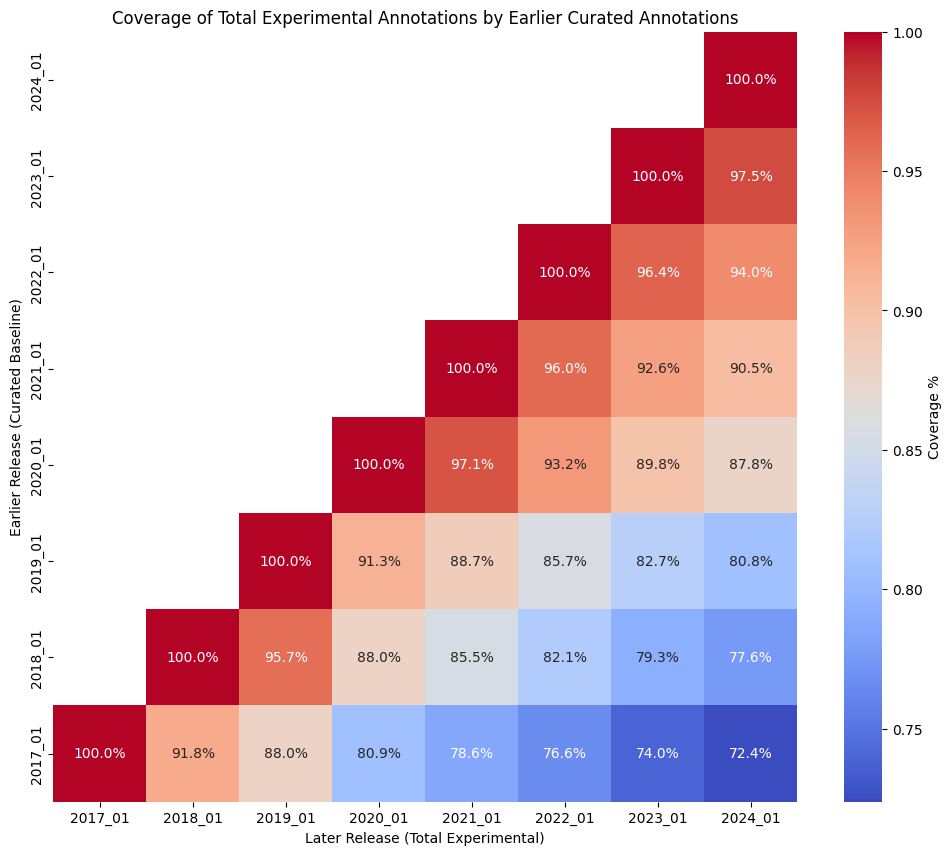

In [2]:
# Initialize results matrix for total coverage
matrix_total = pd.DataFrame(index=releases, columns=releases, dtype=float)

print("Starting computation for total coverage...")

for i, earlier_release in enumerate(releases):
    # Retrieve Curated Annotations from cache (populated in previous cell)
    curated_earlier = curated_annotations_cache[earlier_release]
    
    # We analyze against all releases, starting from the current one forward
    for j in range(i, len(releases)):
        later_release = releases[j]
        
        # Check cache for experimental annotations (populated in previous cell)
        if later_release not in exp_annotations_cache:
            # Fallback if not cached yet (e.g. if cell 2 is run before cell 1 finishes iterating)
            print(f"Loading experimental annotations for {later_release}...")
            exp_annotations_cache[later_release] = load_annotations_set(later_release, "BPO_exp_annotations")
        exp_later = exp_annotations_cache[later_release]
        
        # Total experimental annotations = Exp_Later
        total_experimental = exp_later
        
        if len(total_experimental) == 0:
            coverage = 0.0
        else:
            # Correctly predicted = total_experimental INTERSECT curated earlier
            correctly_predicted = total_experimental.intersection(curated_earlier)
            coverage = len(correctly_predicted) / len(total_experimental)
        
        matrix_total.loc[earlier_release, later_release] = coverage

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(matrix_total.iloc[::-1], annot=True, fmt=".1%", cmap="coolwarm", cbar_kws={'label': 'Coverage %'})
plt.title("Coverage of Total Experimental Annotations by Earlier Curated Annotations")
plt.xlabel("Later Release (Total Experimental)")
plt.ylabel("Earlier Release (Curated Baseline)")
plt.show()

Starting computation for Experimental vs Experimental coverage...


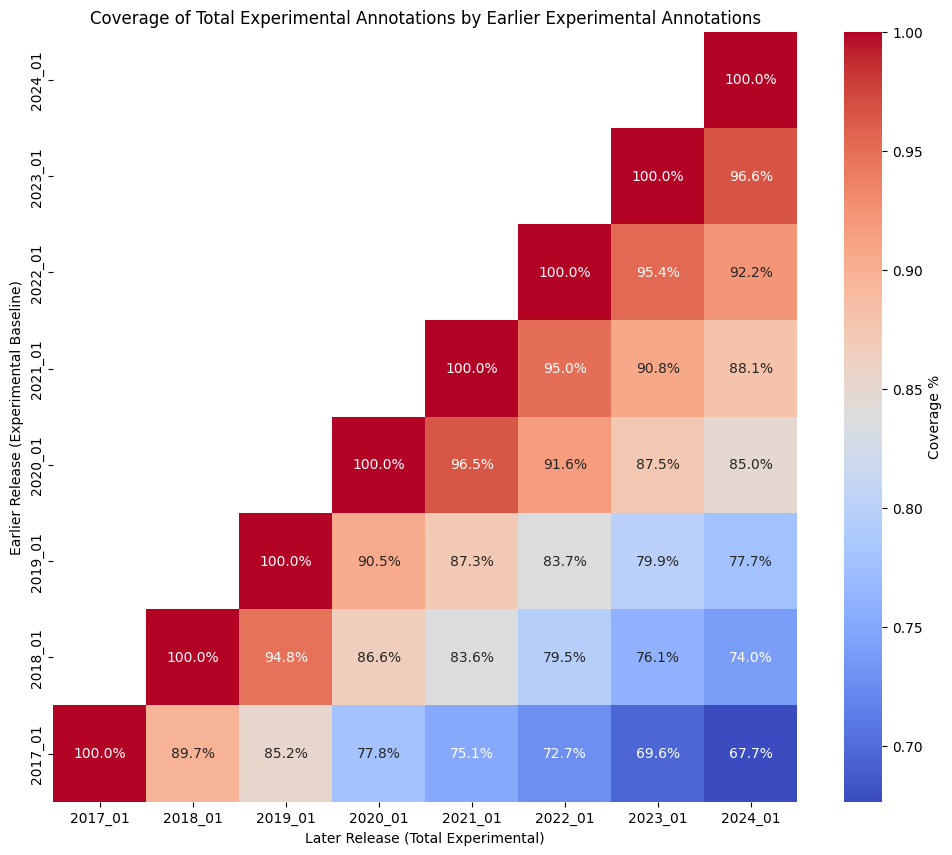

In [3]:
# Initialize results matrix for Total Experimental by Earlier Experimental
matrix_exp_vs_exp = pd.DataFrame(index=releases, columns=releases, dtype=float)

print("Starting computation for Experimental vs Experimental coverage...")

# Cursing through releases
for i, earlier_release in enumerate(releases):
    # Load Earlier Experimental Annotations
    # Checking cache (should be populated from previous cells, but good practice to check)
    if earlier_release not in exp_annotations_cache:
        print(f"Loading experimental annotations for {earlier_release}...")
        exp_annotations_cache[earlier_release] = load_annotations_set(earlier_release, "BPO_exp_annotations")
    exp_earlier = exp_annotations_cache[earlier_release]

    # Compare against subsequent releases (including itself, which should be 100%)
    for j in range(i, len(releases)):
        later_release = releases[j]
        
        # Load Later Experimental Annotations
        if later_release not in exp_annotations_cache:
            print(f"Loading experimental annotations for {later_release}...")
            exp_annotations_cache[later_release] = load_annotations_set(later_release, "BPO_exp_annotations")
        exp_later = exp_annotations_cache[later_release]
        
        if len(exp_later) == 0:
            coverage = 0.0
        else:
            # Overlap between earlier experimental and later experimental
            # Essentially: How much of Today's Experimental data was already known Yesterday?
            overlap = exp_later.intersection(exp_earlier)
            coverage = len(overlap) / len(exp_later)
        
        matrix_exp_vs_exp.loc[earlier_release, later_release] = coverage

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(matrix_exp_vs_exp.iloc[::-1], annot=True, fmt=".1%", cmap="coolwarm", cbar_kws={'label': 'Coverage %'})
plt.title("Coverage of Total Experimental Annotations by Earlier Experimental Annotations")
plt.xlabel("Later Release (Total Experimental)")
plt.ylabel("Earlier Release (Experimental Baseline)")
plt.show()

Loading IC values from /home/atoffano/PFP_layer/data/H30/IA_H30_BPO.tsv...
Starting weighted computation...


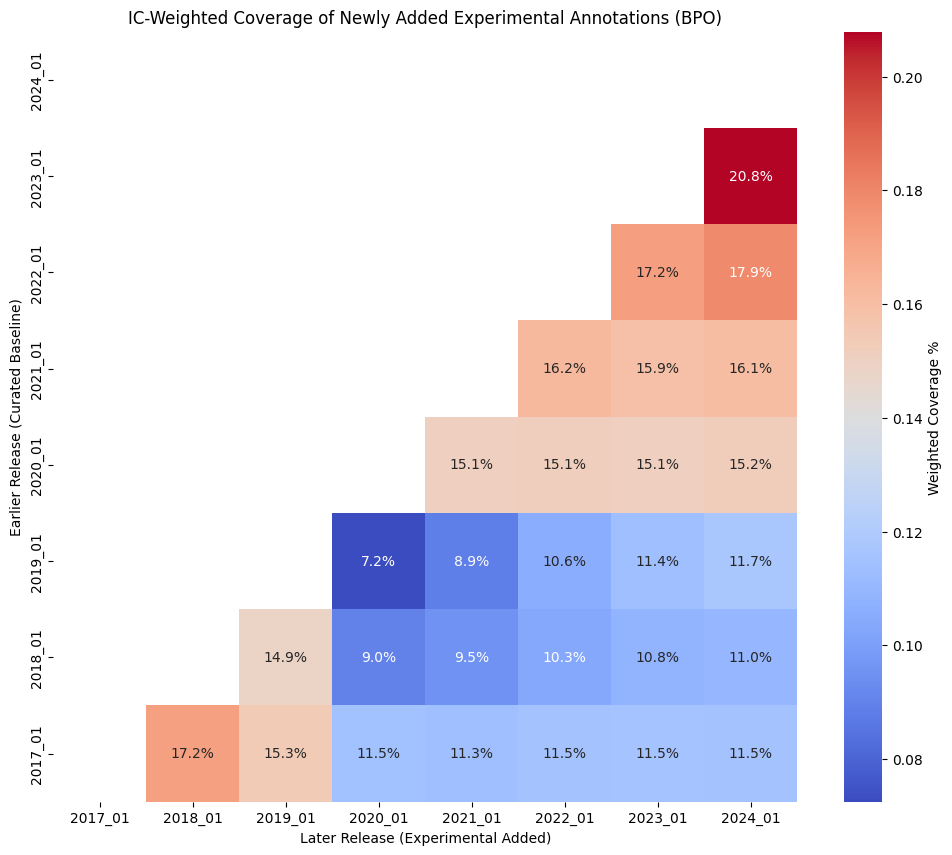

In [6]:
# Load Information Content (IC) for BPO
ic_file_path = '/home/atoffano/PFP_layer/data/H30/IA_H30_BPO.tsv'
print(f"Loading IC values from {ic_file_path}...")

ic_map = {}
if os.path.exists(ic_file_path):
    with open(ic_file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                term = parts[0]
                try:
                    ic = float(parts[1])
                    ic_map[term] = ic
                except ValueError:
                    pass
else:
    print(f"Error: IC file not found at {ic_file_path}")

# Initialize weighted results matrix
matrix_weighted = pd.DataFrame(index=releases, columns=releases, dtype=float)

print("Starting weighted computation...")

for i, earlier_release in enumerate(releases):
    # Retrieve cached sets from previous execution
    # Ensure checking cache keys exist to avoid KeyError if previous cell wasn't fully run
    if earlier_release not in curated_annotations_cache:
        print(f"Cache miss for curated {earlier_release}, reloading...")
        curated_annotations_cache[earlier_release] = load_annotations_set(earlier_release, "BPO_annotations")
    curated_earlier = curated_annotations_cache[earlier_release]
    
    if earlier_release not in exp_annotations_cache:
        print(f"Cache miss for experimental {earlier_release}, reloading...")
        exp_annotations_cache[earlier_release] = load_annotations_set(earlier_release, "BPO_exp_annotations")
    exp_earlier = exp_annotations_cache[earlier_release]

    for j in range(i + 1, len(releases)):
        later_release = releases[j]
        
        if later_release not in exp_annotations_cache:
             print(f"Cache miss for experimental {later_release}, reloading...")
             exp_annotations_cache[later_release] = load_annotations_set(later_release, "BPO_exp_annotations")
        exp_later = exp_annotations_cache[later_release]
        
        # newly added experimental annotations
        newly_added = exp_later - exp_earlier
        
        if len(newly_added) == 0:
            coverage = 0.0
        else:
            # Correctly predicted
            correctly_predicted = newly_added.intersection(curated_earlier)
            
            # Weighted calculation
            # Sum of ICs of correctly predicted annotations. (entry_id, term) -> term is at index 1
            weighted_numerator = sum(ic_map.get(term, 0.0) for _, term in correctly_predicted)
            
            # Sum of ICs of all newly added annotations
            weighted_denominator = sum(ic_map.get(term, 0.0) for _, term in newly_added)
            
            if weighted_denominator > 0:
                coverage = weighted_numerator / weighted_denominator
            else:
                coverage = 0.0
        
        matrix_weighted.loc[earlier_release, later_release] = coverage

# Plotting Weighted Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(matrix_weighted.iloc[::-1], annot=True, fmt=".1%", cmap="coolwarm", cbar_kws={'label': 'Weighted Coverage %'})
plt.title("IC-Weighted Coverage of Newly Added Experimental Annotations (BPO)")
plt.xlabel("Later Release (Experimental Added)")
plt.ylabel("Earlier Release (Curated Baseline)")
plt.show()